In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df_touchpoints = pd.read_csv("../data/touchpoints_clean.csv")

# Étape 1 : Exploration des parcours (Léopold)

In [2]:
# Aperçu des données
df_touchpoints.head()

,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0


In [3]:
# Répartition des conversions
value_counts = df_touchpoints['is_last_before_conversion'].value_counts()
print("Répartition is_last_before_conversion :")
print(value_counts)

Répartition is_last_before_conversion :
is_last_before_conversion
0    593686
1     99096
Name: count, dtype: int64


Nombre moyen de touchpoints par client : 14.48


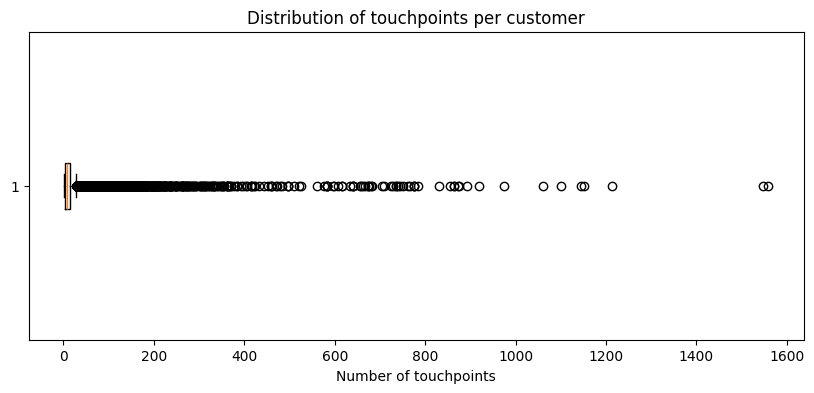

In [4]:
# Nombre moyen de touchpoints par client
touchpoints_per_client = df_touchpoints.groupby('customer_id').size()
average_touchpoints = touchpoints_per_client.mean()
print(f"Nombre moyen de touchpoints par client : {average_touchpoints:.2f}")

# Boxplot de la répartition
plt.figure(figsize=(10, 4))
plt.boxplot(touchpoints_per_client, vert=False)
plt.title('Distribution of touchpoints per customer')
plt.xlabel('Number of touchpoints')
plt.show()

In [5]:
# Durée moyenne d'un parcours
df_touchpoints['timestamp'] = pd.to_datetime(df_touchpoints['timestamp'])

first = df_touchpoints.groupby('customer_id')['timestamp'].min()
last = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1].groupby('customer_id')['timestamp'].max()

average_duration = ((last - first).dropna().dt.total_seconds() / 3600).mean()
print(f"Durée moyenne d'un parcours : {average_duration:.2f} heures")

Durée moyenne d'un parcours : 3718.36 heures


In [6]:
# Canaux les plus présents en première et dernière position
first_touch_exp = df_touchpoints.groupby('customer_id').first()
channel_premiere_position = first_touch_exp['channel'].value_counts()

last_touch_exp = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1].groupby('customer_id').last()
channel_derniere_position = last_touch_exp['channel'].value_counts()

print("Canaux en première position :")
print(channel_premiere_position)
print("\nCanaux en dernière position avant conversion :")
print(channel_derniere_position)

Canaux en première position :
channel
display        12950
social         12866
affiliate      12753
email           4669
retargeting     4596
Name: count, dtype: int64

Canaux en dernière position avant conversion :
channel
email          7019
retargeting    6967
direct         6884
search_paid    6883
Name: count, dtype: int64


In [7]:
# Analyse des séquences - Top 5 trigrammes
sequences = df_touchpoints.sort_values('timestamp').groupby('customer_id')['channel'].apply(list)
trigrams = Counter(gram for s in sequences for gram in zip(s, s[1:], s[2:]))

print("Top 5 trigrammes :")
for seq, n in trigrams.most_common(5):
    print(f"  {' → '.join(seq)} : {n}")

# Comparaison touchpoints convertis vs non convertis
lengths = df_touchpoints.groupby('customer_id')['channel'].count()
converted_exp = df_touchpoints[df_touchpoints['is_last_before_conversion'] == 1]['customer_id'].unique()

print(f"\nConvertis     : {lengths[lengths.index.isin(converted_exp)].mean():.1f} touchpoints en moyenne")
print(f"Non convertis : {lengths[~lengths.index.isin(converted_exp)].mean():.1f} touchpoints en moyenne")

Top 5 trigrammes :
  affiliate → display → social : 2788
  affiliate → social → social : 2775
  display → social → display : 2767
  social → social → display : 2759
  social → affiliate → display : 2757

Convertis     : 22.1 touchpoints en moyenne
Non convertis : 4.0 touchpoints en moyenne


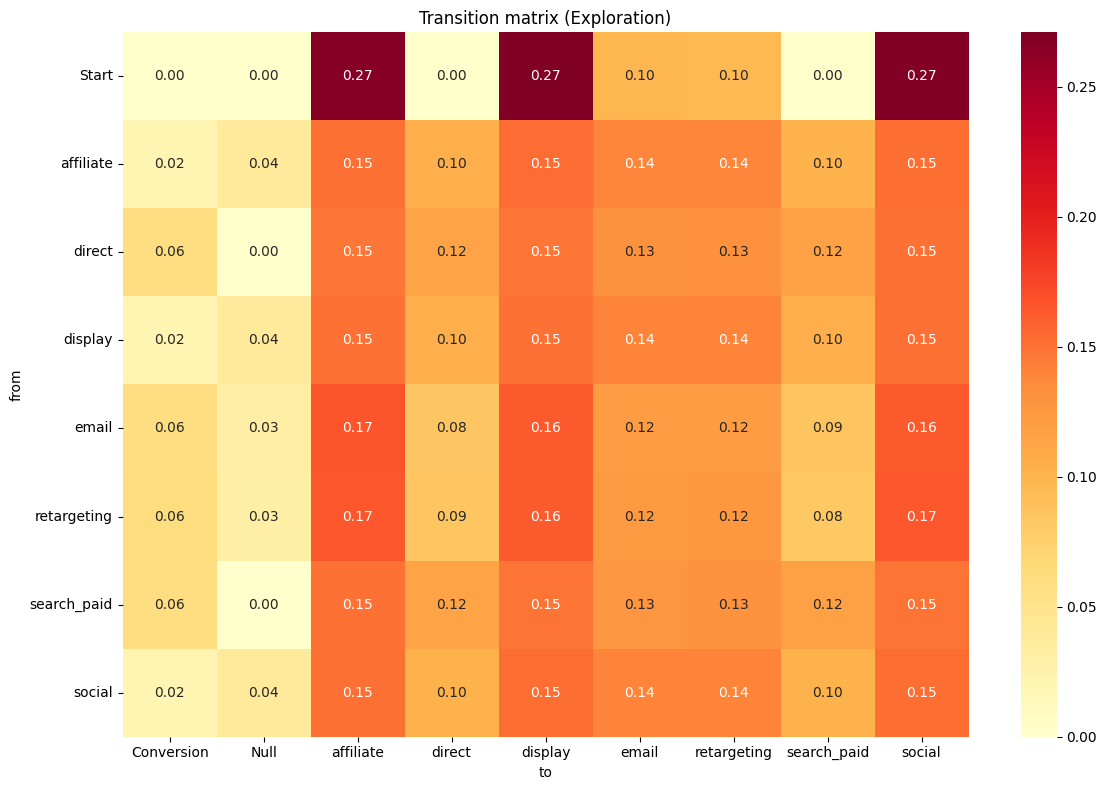

In [8]:
# Matrice de transition (exploration)
df_sorted = df_touchpoints.sort_values(['customer_id', 'timestamp'])
transitions = []

for cid, group in df_sorted.groupby('customer_id'):
    channels_exp = group['channel'].tolist()
    end = 'Conversion' if group['is_last_before_conversion'].max() == 1 else 'Null'
    for a, b in zip(['Start'] + channels_exp, channels_exp + [end]):
        transitions.append((a, b))

trans_df = pd.DataFrame(transitions, columns=['from', 'to'])
matrix_exploration = pd.crosstab(trans_df['from'], trans_df['to'], normalize='index').round(3)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matrix_exploration, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title("Transition matrix (Exploration)")
plt.tight_layout()
plt.show()

# Étape 2 : Modèles d'Attribution Heuristiques (Younes)

In [9]:
# FIRST TOUCH

converted_ids = df_touchpoints[df_touchpoints['converted'] == 1]['customer_id'].unique()
df_converted = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]

first_touch_attribution = (
    df_converted[df_converted['position'] == 1]
    .groupby('channel')
    .size()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
first_touch_attribution['%'] = (
    first_touch_attribution['conversions'] / first_touch_attribution['conversions'].sum() * 100
).round(1)

first_touch_attribution

,channel,conversions,%
1,display,44804,30.0
4,social,44672,30.0
0,affiliate,44487,29.8
2,email,7612,5.1
3,retargeting,7575,5.1


In [10]:
# répartition budget first touch
first_channel = (
    df_converted[df_converted['position'] == 1][['customer_id', 'channel']]
    .rename(columns={'channel': 'first_channel'})
)

cost_per_customer = df_converted.groupby('customer_id')['cost'].sum().reset_index()

df_budget = cost_per_customer.merge(first_channel, on='customer_id')

budget_first_touch = (
    df_budget.groupby('first_channel')['cost']
    .sum()
    .reset_index()
    .rename(columns={'first_channel': 'channel', 'cost': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_first_touch['budget'] = budget_first_touch['budget'].round(2)
budget_first_touch['%'] = (
    budget_first_touch['budget'] / budget_first_touch['budget'].sum() * 100
).round(1)

budget_first_touch

,channel,budget,%
0,display,2944164.83,32.3
1,affiliate,2935242.72,32.2
2,social,2921621.95,32.1
3,retargeting,160888.14,1.8
4,email,149597.36,1.6


In [11]:
# LAST TOUCH

df_converted_last_touch = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]

last_touch_attribution = (
    df_converted_last_touch[df_converted_last_touch['position'] == df_converted_last_touch['position'].max()]
    .groupby('channel')
    .size()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
last_touch_attribution['%'] = (
    last_touch_attribution['conversions'] / last_touch_attribution['conversions'].sum() * 100
).round(1)

last_touch_attribution

,channel,conversions,%
2,retargeting,3108,25.6
0,direct,3084,25.4
3,search_paid,2980,24.5
1,email,2976,24.5


In [12]:
# répartition budget last_touch
last_channel = (
    df_converted_last_touch.loc[df_converted_last_touch.groupby('customer_id')['position'].idxmax(), ['customer_id', 'channel']]
    .rename(columns={'channel': 'last_channel'})
)

cost_per_customer = df_converted_last_touch.groupby('customer_id')['cost'].sum().reset_index()

df_budget_last = cost_per_customer.merge(last_channel, on='customer_id')

budget_last_touch = (
    df_budget_last.groupby('last_channel')['cost']
    .sum()
    .reset_index()
    .rename(columns={'last_channel': 'channel', 'cost': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_last_touch['budget'] = budget_last_touch['budget'].round(2)
budget_last_touch['%'] = (
    budget_last_touch['budget'] / budget_last_touch['budget'].sum() * 100
).round(1)

budget_last_touch

,channel,budget,%
0,retargeting,128190.45,25.6
1,search_paid,120857.56,24.2
2,email,119933.03,24.0
3,direct,115461.95,23.1
4,affiliate,5601.05,1.1
5,social,5203.39,1.0
6,display,4584.99,0.9


In [13]:
# LINEAIRE

df_converted_linear = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)].copy()

df_converted_linear['credit'] = df_converted_linear.groupby('customer_id')['channel'].transform(lambda x: 1 / len(x))

linear_attribution = (
    df_converted_linear.groupby('channel')['credit']
    .sum()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
linear_attribution['%'] = (
    linear_attribution['conversions'] / linear_attribution['conversions'].sum() * 100
).round(1)

linear_attribution

,channel,conversions,%
2,display,4887.818833,17.6
0,affiliate,4847.514096,17.5
6,social,4846.290794,17.5
3,email,3850.989440,13.9
4,retargeting,3821.402107,13.8
1,direct,2761.845363,10.0
5,search_paid,2737.139368,9.9


In [14]:
# répartition budget linéaire

cost_per_customer = df_converted_linear.groupby('customer_id')['cost'].sum().reset_index()

df_linear_budget = (
    df_converted_linear[['customer_id', 'channel', 'credit']]
    .merge(cost_per_customer, on='customer_id')
)
df_linear_budget['budget_attributed'] = df_linear_budget['credit'] * df_linear_budget['cost']

budget_linear = (
    df_linear_budget.groupby('channel')['budget_attributed']
    .sum()
    .reset_index()
    .rename(columns={'budget_attributed': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

budget_linear['budget'] = budget_linear['budget'].round(2)
budget_linear['%'] = (
    budget_linear['budget'] / budget_linear['budget'].sum() * 100
).round(1)

budget_linear

,channel,budget,%
0,affiliate,87972.82,17.6
1,social,82238.22,16.5
2,display,80813.58,16.2
3,retargeting,70088.49,14.0
4,email,66556.54,13.3
5,search_paid,57608.42,11.5
6,direct,54554.37,10.9


In [15]:
# MODEL U

df_converted_u = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)].copy()

def u_shape_credit(group):
    n = len(group)
    group = group.sort_values('position')
    credits = pd.Series(0.0, index=group.index)

    if n == 1:
        credits.iloc[0] = 1.0
    elif n == 2:
        credits.iloc[0] = 0.5
        credits.iloc[1] = 0.5
    else:
        credits.iloc[0] = 0.4              
        credits.iloc[-1] = 0.4             
        credits.iloc[1:-1] = 0.2 / (n - 2) 

    return credits

df_converted_u['credit'] = (
    df_converted_u.groupby('customer_id', group_keys=False)
    .apply(u_shape_credit, include_groups=False)
)

u_shape_attribution = (
    df_converted_u.groupby('channel')['credit']
    .sum()
    .reset_index(name='conversions')
    .sort_values('conversions', ascending=False)
)
u_shape_attribution['%'] = (
    u_shape_attribution['conversions'] / u_shape_attribution['conversions'].sum() * 100
).round(1)

u_shape_attribution

,channel,conversions,%
2,display,4540.079849,16.4
6,social,4508.623860,16.2
0,affiliate,4452.207794,16.0
3,email,4104.053301,14.8
4,retargeting,4082.599215,14.7
1,direct,3033.525804,10.9
5,search_paid,3031.910177,10.9


In [16]:
# répartition budget model U

cost_per_customer = df_converted_u.groupby('customer_id')['cost'].sum().reset_index()

df_u_budget = (
    df_converted_u[['customer_id', 'channel', 'credit']]
    .merge(cost_per_customer, on='customer_id')
)
df_u_budget['budget_attributed'] = df_u_budget['credit'] * df_u_budget['cost']

df_u_budget = (
    df_u_budget.groupby('channel')['budget_attributed']
    .sum()
    .reset_index()
    .rename(columns={'budget_attributed': 'budget'})
    .sort_values('budget', ascending=False)
    .reset_index(drop=True)
)

df_u_budget['budget'] = df_u_budget['budget'].round(2)
df_u_budget['%'] = (
    df_u_budget['budget'] / df_u_budget['budget'].sum() * 100
).round(1)

df_u_budget

,channel,budget,%
0,affiliate,83008.83,16.6
1,social,78508.24,15.7
2,display,77589.93,15.5
3,retargeting,72842.36,14.6
4,email,70626.34,14.1
5,search_paid,59999.53,12.0
6,direct,57257.21,11.5


# Étape 3 : Modèle de Markov

In [17]:
# Construction des parcours avec états Start, Conversion, Null

def build_paths(df):
    """Construit les parcours avec états spéciaux Start et Conversion/Null"""
    paths = []
    
    for customer_id, group in df.groupby('customer_id'):
        group = group.sort_values('position')
        
        # Séquence de canaux
        channels = ['Start'] + group['channel'].tolist()
        
        # Ajouter l'état final
        if group['converted'].max() == 1:
            channels.append('Conversion')
        else:
            channels.append('Null')
        
        paths.append(channels)
    
    return paths

# Construire tous les parcours
paths = build_paths(df_touchpoints)

# Aperçu des parcours
print(f"Nombre de parcours : {len(paths)}")
print(f"\nExemples de parcours convertis :")
converted_paths = [p for p in paths if p[-1] == 'Conversion'][:5]
for p in converted_paths:
    print(f"  {' → '.join(p)}")

print(f"\nExemples de parcours non convertis :")
null_paths = [p for p in paths if p[-1] == 'Null'][:3]
for p in null_paths:
    print(f"  {' → '.join(p)}")

Nombre de parcours : 47834

Exemples de parcours convertis :
  Start → affiliate → social → direct → affiliate → social → retargeting → Conversion
  Start → social → display → social → display → display → affiliate → social → affiliate → social → direct → retargeting → email → display → search_paid → display → search_paid → retargeting → direct → display → affiliate → display → retargeting → retargeting → email → search_paid → affiliate → display → social → email → search_paid → Conversion
  Start → affiliate → email → display → affiliate → retargeting → email → social → email → direct → search_paid → Conversion
  Start → social → social → affiliate → email → affiliate → affiliate → email → direct → retargeting → Conversion
  Start → email → social → display → social → display → social → affiliate → affiliate → display → social → affiliate → social → direct → email → social → display → retargeting → retargeting → direct → search_paid → direct → display → retargeting → email → retargeti

In [18]:
# Construction de la matrice de transition

from collections import defaultdict

def build_transition_matrix(paths):
    """Construit la matrice de transition de Markov"""
    transitions = defaultdict(lambda: defaultdict(int))
    
    for path in paths:
        for i in range(len(path) - 1):
            current_state = path[i]
            next_state = path[i + 1]
            transitions[current_state][next_state] += 1
    
    # Convertir en DataFrame avec probabilités
    all_states = set()
    for path in paths:
        all_states.update(path)
    all_states = sorted(list(all_states))
    
    matrix = pd.DataFrame(0.0, index=all_states, columns=all_states)
    
    for from_state in transitions:
        total = sum(transitions[from_state].values())
        for to_state in transitions[from_state]:
            matrix.loc[from_state, to_state] = transitions[from_state][to_state] / total
    
    # États absorbants : Conversion et Null restent dans leur état (probabilité = 1)
    matrix.loc['Conversion', 'Conversion'] = 1.0
    matrix.loc['Null', 'Null'] = 1.0
    
    return matrix

# Construire la matrice
transition_matrix = build_transition_matrix(paths)

# Afficher la matrice de transition (probabilités arrondies)
print("Matrice de transition (probabilités):")
transition_matrix.round(3)

Matrice de transition (probabilités):


,Conversion,Null,Start,affiliate,direct,display,email,retargeting,search_paid,social
Conversion,1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Null,0.000,1.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Start,0.000,0.000,0.0,0.267,0.000,0.271,0.098,0.096,0.000,0.269
affiliate,0.005,0.039,0.0,0.190,0.074,0.192,0.117,0.117,0.075,0.192
direct,0.089,0.000,0.0,0.098,0.149,0.100,0.158,0.160,0.146,0.100
display,0.005,0.039,0.0,0.193,0.074,0.189,0.117,0.116,0.073,0.193
email,0.070,0.032,0.0,0.126,0.116,0.125,0.144,0.145,0.116,0.126
retargeting,0.069,0.031,0.0,0.126,0.116,0.126,0.145,0.146,0.116,0.125
search_paid,0.090,0.000,0.0,0.101,0.147,0.098,0.159,0.158,0.147,0.100
social,0.005,0.039,0.0,0.191,0.074,0.192,0.117,0.117,0.073,0.191


In [19]:
# Calcul de la probabilité de conversion totale (sans suppression)

def calculate_conversion_probability(matrix, max_iterations=100):
    """
    Calcule la probabilité d'atteindre Conversion depuis Start
    en utilisant l'absorption dans une chaîne de Markov
    """
    # Identifier les canaux (états non absorbants)
    channels = [s for s in matrix.index if s not in ['Start', 'Conversion', 'Null']]
    transient_states = ['Start'] + channels
    absorbing_states = ['Conversion', 'Null']
    
    # Si pas d'états transitoires, retourner 0
    if len(transient_states) == 0:
        return 0.0
    
    # Matrice Q (transitions entre états transitoires)
    Q = matrix.loc[transient_states, transient_states].values
    
    # Matrice R (transitions vers états absorbants)
    R = matrix.loc[transient_states, absorbing_states].values
    
    # Calculer la matrice fondamentale N = (I - Q)^(-1)
    I = np.eye(len(transient_states))
    try:
        N = np.linalg.inv(I - Q)
    except np.linalg.LinAlgError:
        # Si singulière, utiliser pseudo-inverse
        N = np.linalg.pinv(I - Q)
    
    # Probabilités d'absorption B = N * R
    B = N @ R
    
    # Probabilité d'atteindre Conversion depuis Start (index 0)
    conversion_idx = absorbing_states.index('Conversion')
    prob_conversion = B[0, conversion_idx]
    
    return prob_conversion

# Calcul de la probabilité de conversion de base
base_conversion_prob = calculate_conversion_probability(transition_matrix)
print(f"Probabilité de conversion de base : {base_conversion_prob:.4f} ({base_conversion_prob*100:.2f}%)")

Probabilité de conversion de base : 0.5802 (58.02%)


In [20]:
# Calcul de l'effet de suppression pour chaque canal

def calculate_removal_effect(matrix, channel_to_remove):
    """
    Simule la suppression d'un canal et calcule la nouvelle probabilité de conversion.
    Les transitions vers ce canal sont redirigées vers 'Null'.
    """
    modified_matrix = matrix.copy()
    
    # Rediriger toutes les transitions vers ce canal vers Null
    for state in modified_matrix.index:
        if state != channel_to_remove:
            prob_to_removed = modified_matrix.loc[state, channel_to_remove]
            if prob_to_removed > 0:
                modified_matrix.loc[state, 'Null'] += prob_to_removed
                modified_matrix.loc[state, channel_to_remove] = 0
    
    # Mettre les transitions du canal supprimé à zéro
    modified_matrix.loc[channel_to_remove, :] = 0
    modified_matrix.loc[:, channel_to_remove] = 0
    
    return calculate_conversion_probability(modified_matrix)

# Identifier les canaux (exclure Start, Conversion, Null)
channels = [s for s in transition_matrix.index if s not in ['Start', 'Conversion', 'Null']]

# Calculer l'effet de suppression pour chaque canal
removal_effects = []
for channel in channels:
    prob_without = calculate_removal_effect(transition_matrix, channel)
    removal_effect = base_conversion_prob - prob_without
    removal_effects.append({
        'channel': channel,
        'prob_with': base_conversion_prob,
        'prob_without': prob_without,
        'removal_effect': removal_effect,
        'removal_effect_pct': (removal_effect / base_conversion_prob) * 100 if base_conversion_prob > 0 else 0
    })

df_removal = pd.DataFrame(removal_effects).sort_values('removal_effect', ascending=False)
df_removal['removal_effect_pct'] = df_removal['removal_effect_pct'].round(1)

print("Effet de suppression par canal :")
print("(Plus l'effet est élevé, plus le canal est important)")
df_removal

Effet de suppression par canal :
(Plus l'effet est élevé, plus le canal est important)


,channel,prob_with,prob_without,removal_effect,removal_effect_pct
2,display,0.580194,0.142550,0.437644,75.4
6,social,0.580194,0.142607,0.437587,75.4
0,affiliate,0.580194,0.143301,0.436893,75.3
3,email,0.580194,0.145078,0.435116,75.0
4,retargeting,0.580194,0.145329,0.434865,75.0
1,direct,0.580194,0.200054,0.380140,65.5
5,search_paid,0.580194,0.200241,0.379953,65.5


In [21]:
# Attribution Markov basée sur les effets de suppression

# Normaliser les effets de suppression pour obtenir les poids d'attribution
total_removal_effect = df_removal['removal_effect'].sum()

markov_attribution = df_removal[['channel', 'removal_effect']].copy()
markov_attribution['attribution_weight'] = markov_attribution['removal_effect'] / total_removal_effect

# Nombre total de conversions
total_conversions = df_touchpoints[df_touchpoints['converted'] == 1]['customer_id'].nunique()

# Calculer les conversions attribuées
markov_attribution['conversions'] = (markov_attribution['attribution_weight'] * total_conversions).round(2)
markov_attribution['%'] = (markov_attribution['attribution_weight'] * 100).round(1)

markov_attribution = markov_attribution[['channel', 'conversions', '%']].sort_values('conversions', ascending=False).reset_index(drop=True)

print(f"Attribution Markov (basée sur {total_conversions} conversions):")
markov_attribution

Attribution Markov (basée sur 27753 conversions):


,channel,conversions,%
0,display,4128.18,14.9
1,social,4127.65,14.9
2,affiliate,4121.10,14.8
3,email,4104.34,14.8
4,retargeting,4101.97,14.8
5,direct,3585.76,12.9
6,search_paid,3584.00,12.9


In [22]:
# Répartition du budget selon le modèle Markov

# Calculer le budget total
total_budget = df_touchpoints[df_touchpoints['customer_id'].isin(converted_ids)]['cost'].sum()

# Allouer le budget selon les poids Markov
budget_markov = markov_attribution[['channel', '%']].copy()
budget_markov['budget'] = (budget_markov['%'] / 100 * total_budget).round(2)

# Réordonner les colonnes
budget_markov = budget_markov[['channel', 'budget', '%']].sort_values('budget', ascending=False).reset_index(drop=True)

print(f"Répartition du budget selon le modèle Markov (budget total: {total_budget:.2f}€):")
budget_markov

Répartition du budget selon le modèle Markov (budget total: 499832.43€):


,channel,budget,%
0,display,74475.03,14.9
1,social,74475.03,14.9
2,affiliate,73975.20,14.8
3,email,73975.20,14.8
4,retargeting,73975.20,14.8
5,direct,64478.38,12.9
6,search_paid,64478.38,12.9


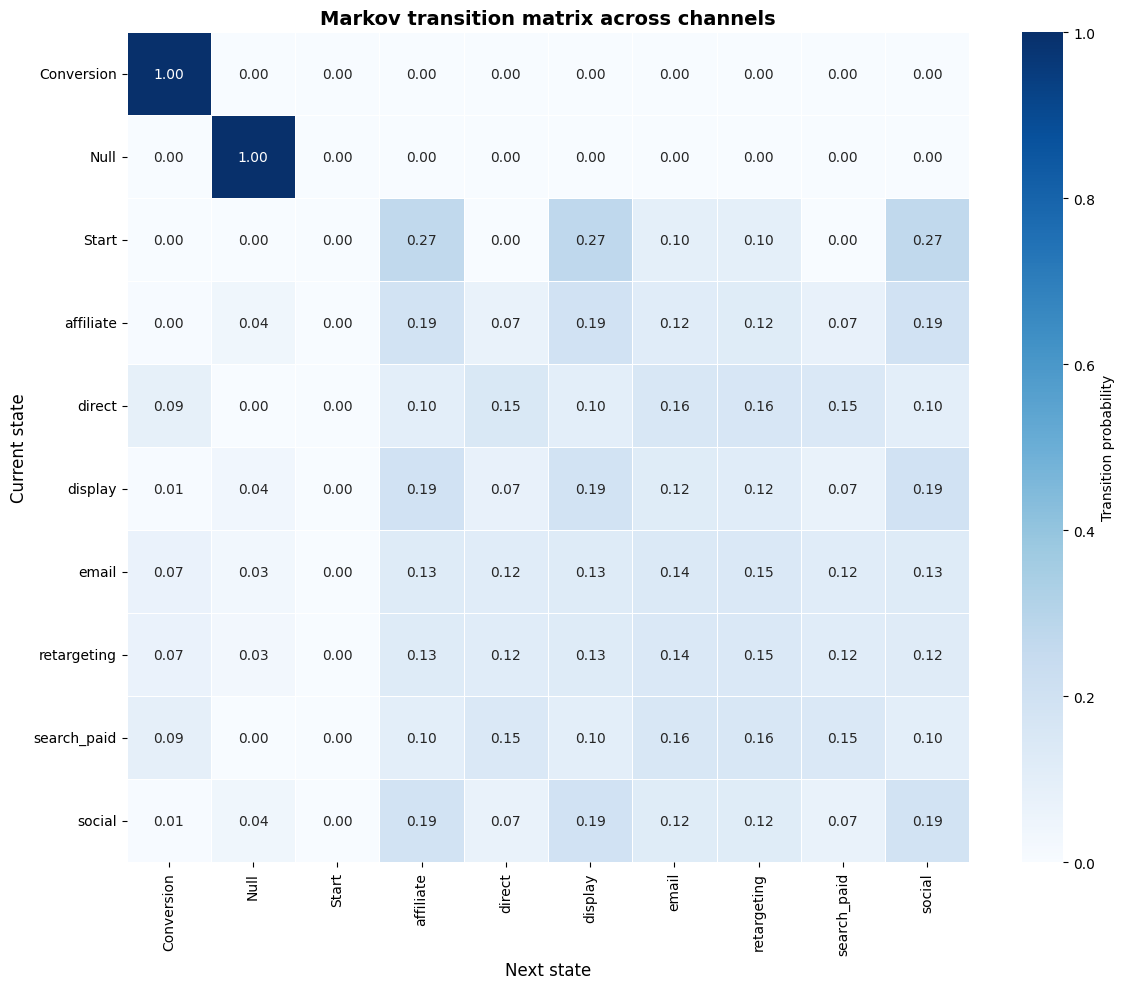

In [23]:
# Visualisation de la matrice de transition (heatmap)
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))

# Filtrer pour ne montrer que les transitions significatives
significant_matrix = transition_matrix.copy()

sns.heatmap(
    significant_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': 'Transition probability'},
    linewidths=0.5
)

ax.set_title('Markov transition matrix across channels', fontsize=14, fontweight='bold')
ax.set_xlabel('Next state', fontsize=12)
ax.set_ylabel('Current state', fontsize=12)

plt.tight_layout()
plt.show()

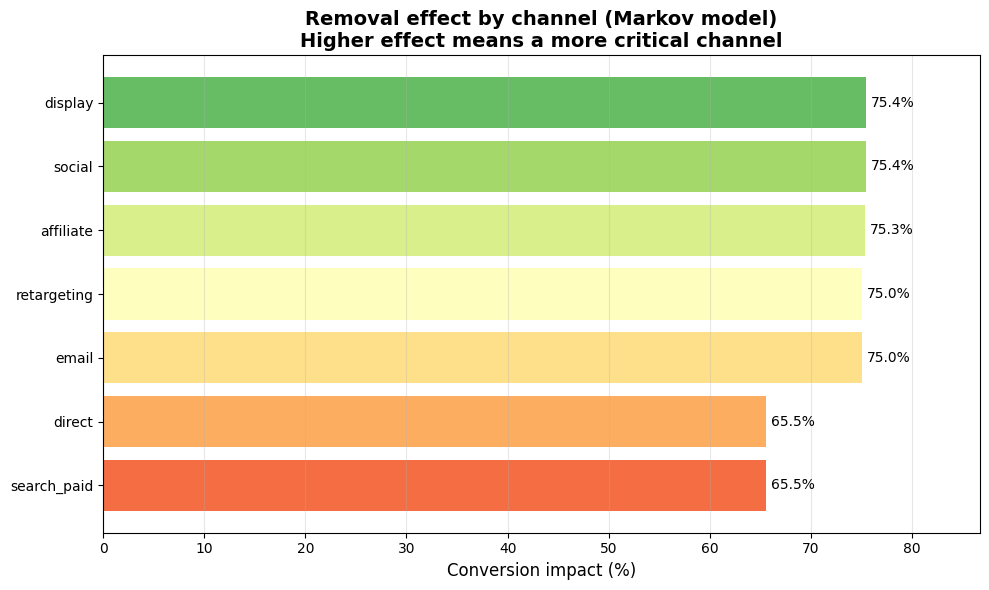


 Interprétation :
Les canaux avec un effet de suppression élevé sont essentiels au parcours de conversion.
Supprimer ces canaux causerait une baisse significative du taux de conversion.


In [24]:
# Visualisation des effets de suppression

fig, ax = plt.subplots(figsize=(10, 6))

df_viz = df_removal.sort_values('removal_effect_pct', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(df_viz)))

bars = ax.barh(df_viz['channel'], df_viz['removal_effect_pct'], color=colors)

ax.set_xlabel('Conversion impact (%)', fontsize=12)
ax.set_title('Removal effect by channel (Markov model)\nHigher effect means a more critical channel', fontsize=14, fontweight='bold')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, df_viz['removal_effect_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, df_viz['removal_effect_pct'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interprétation :")
print("Les canaux avec un effet de suppression élevé sont essentiels au parcours de conversion.")
print("Supprimer ces canaux causerait une baisse significative du taux de conversion.")

# Étape 4 : Comparaison et Analyse des Modèles

In [25]:
# Tableau comparatif : répartition du budget par canal selon chaque modèle

# Préparer les DataFrames pour la comparaison
comparison_data = []

# Pour chaque canal, collecter les % de chaque modèle
all_channels = sorted(budget_first_touch['channel'].unique())

for ch in all_channels:
    row = {'channel': ch}
    
    # First Touch
    ft = budget_first_touch[budget_first_touch['channel'] == ch]['%']
    row['First Touch (%)'] = ft.values[0] if len(ft) > 0 else 0
    
    # Last Touch
    lt = budget_last_touch[budget_last_touch['channel'] == ch]['%']
    row['Last Touch (%)'] = lt.values[0] if len(lt) > 0 else 0
    
    # Linéaire
    lin = budget_linear[budget_linear['channel'] == ch]['%']
    row['Linéaire (%)'] = lin.values[0] if len(lin) > 0 else 0
    
    # Modèle U
    u = df_u_budget[df_u_budget['channel'] == ch]['%']
    row['Modèle U (%)'] = u.values[0] if len(u) > 0 else 0
    
    # Markov
    mk = budget_markov[budget_markov['channel'] == ch]['%']
    row['Markov (%)'] = mk.values[0] if len(mk) > 0 else 0
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('channel')

print("Tableau comparatif : Part du budget attribuée par canal selon chaque modèle")
df_comparison

Tableau comparatif : Part du budget attribuée par canal selon chaque modèle


,First Touch (%),Last Touch (%),Linéaire (%),Modèle U (%),Markov (%)
channel,,,,,
affiliate,32.2,1.1,17.6,16.6,14.8
display,32.3,0.9,16.2,15.5,14.9
email,1.6,24.0,13.3,14.1,14.8
retargeting,1.8,25.6,14.0,14.6,14.8
social,32.1,1.0,16.5,15.7,14.9


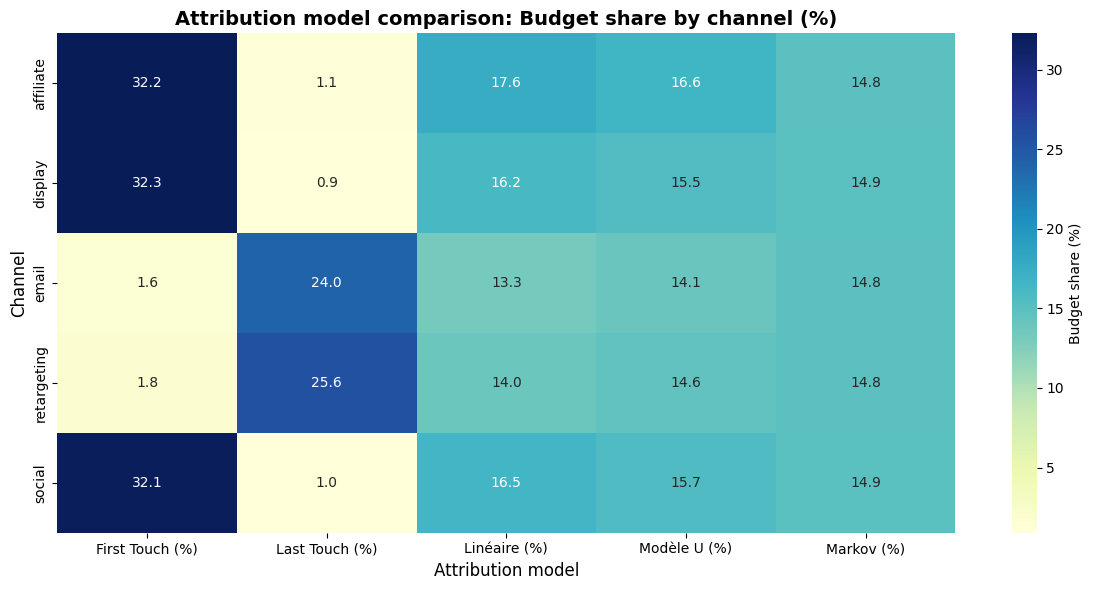

In [26]:
# Visualisation du tableau comparatif (heatmap)

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(df_comparison, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Budget share (%)'})

ax.set_title('Attribution model comparison: Budget share by channel (%)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attribution model', fontsize=12)
ax.set_ylabel('Channel', fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
# Analyse des canaux sur-évalués/sous-évalués par le Last Touch vs Markov

df_comparison['Écart Last Touch - Markov'] = df_comparison['Last Touch (%)'] - df_comparison['Markov (%)']
df_comparison_sorted = df_comparison.sort_values('Écart Last Touch - Markov', ascending=False)

print("Canaux SUR-ÉVALUÉS par le Last Touch (vs Markov) :")
sur_evalues = df_comparison_sorted[df_comparison_sorted['Écart Last Touch - Markov'] > 0]
for idx, row in sur_evalues.iterrows():
    print(f"  • {idx}: +{row['Écart Last Touch - Markov']:.1f}% (Last Touch: {row['Last Touch (%)']:.1f}% vs Markov: {row['Markov (%)']:.1f}%)")

print("\nCanaux SOUS-ÉVALUÉS par le Last Touch (vs Markov) :")
sous_evalues = df_comparison_sorted[df_comparison_sorted['Écart Last Touch - Markov'] < 0]
for idx, row in sous_evalues.iterrows():
    print(f"  • {idx}: {row['Écart Last Touch - Markov']:.1f}% (Last Touch: {row['Last Touch (%)']:.1f}% vs Markov: {row['Markov (%)']:.1f}%)")

Canaux SUR-ÉVALUÉS par le Last Touch (vs Markov) :
  • retargeting: +10.8% (Last Touch: 25.6% vs Markov: 14.8%)
  • email: +9.2% (Last Touch: 24.0% vs Markov: 14.8%)

Canaux SOUS-ÉVALUÉS par le Last Touch (vs Markov) :
  • affiliate: -13.7% (Last Touch: 1.1% vs Markov: 14.8%)
  • social: -13.9% (Last Touch: 1.0% vs Markov: 14.9%)
  • display: -14.0% (Last Touch: 0.9% vs Markov: 14.9%)


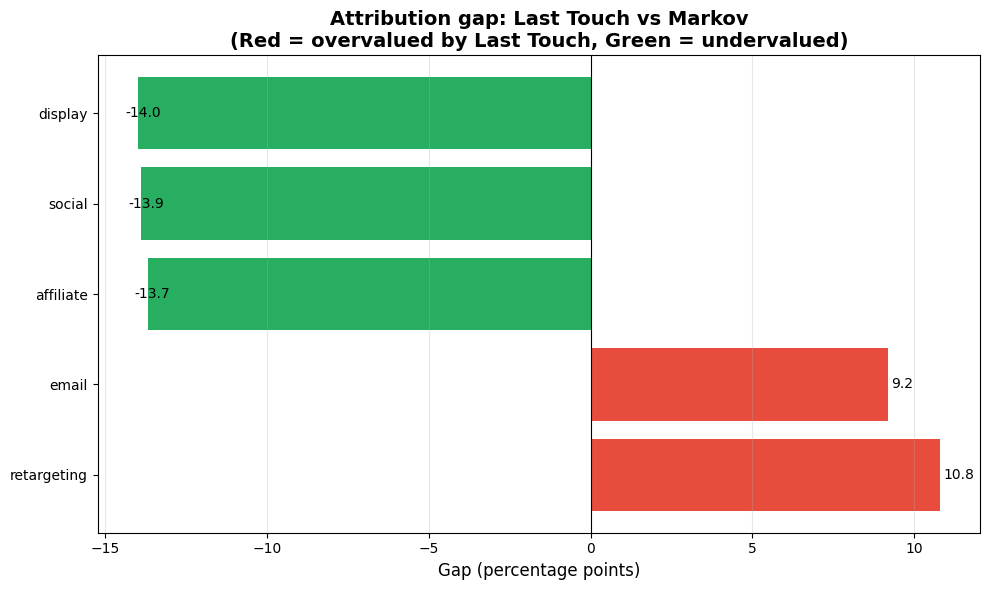


Interprétation :
Si le CMO basait ses décisions sur le Last Touch, les canaux en VERT seraient sous-investis
et les canaux en ROUGE seraient sur-investis par rapport à leur vraie contribution.


In [28]:
# Visualisation de l'écart Last Touch vs Markov

fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_comparison_sorted.reset_index()
colors = ['#e74c3c' if x > 0 else '#27ae60' for x in df_plot['Écart Last Touch - Markov']]

bars = ax.barh(df_plot['channel'], df_plot['Écart Last Touch - Markov'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Gap (percentage points)', fontsize=12)
ax.set_title('Attribution gap: Last Touch vs Markov\n(Red = overvalued by Last Touch, Green = undervalued)', 
             fontsize=14, fontweight='bold')

# Ajouter les valeurs
for bar, val in zip(bars, df_plot['Écart Last Touch - Markov']):
    x_pos = bar.get_width() + 0.1 if bar.get_width() >= 0 else bar.get_width() - 0.4
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("Si le CMO basait ses décisions sur le Last Touch, les canaux en VERT seraient sous-investis")
print("et les canaux en ROUGE seraient sur-investis par rapport à leur vraie contribution.")

# Étape 5 : KPIs par Canal et Campagne

In [29]:
# Chargement des données de campagnes
df_campaigns = pd.read_csv("../data/campaigns.csv")
print("Aperçu des campagnes :")
df_campaigns

Aperçu des campagnes :


,campaign_name,n_touchpoints,n_clients,n_clicks,n_conversions,total_cost,ctr,conversion_rate,cpa,estimated_revenue,roas,primary_channel,start_date,end_date
0,Back_to_School_2023,66227,28490,55034,19562,33567.3308,0.8310,0.6866,1.72,2.322968e+06,69.20,display,2011-02-07 12:50:10.962302767,2011-04-06 00:25:44.582665987
1,Black_Friday_2023,66359,28495,55044,19467,33685.2149,0.8295,0.6832,1.73,2.329076e+06,69.14,display,2011-04-09 12:51:22.412046629,2011-06-06 00:22:19.188015913
2,Spring_Launch_2024,65691,28373,54446,19436,33178.9170,0.8288,0.6850,1.71,2.078515e+06,62.65,display,2011-10-09 12:50:33.541271535,2011-12-06 00:48:13.617049075
3,Summer_Sale_2023,65822,28451,54763,19597,33317.6850,0.8320,0.6888,1.70,1.880754e+06,56.45,display,2010-12-09 12:54:08.618438695,2011-02-04 12:27:29.129422371
4,Valentine_2024,65064,28316,54079,19475,32863.1121,0.8312,0.6878,1.69,7.689825e+05,23.40,display,2011-08-09 12:52:56.051711633,2011-10-05 23:20:29.779553077
5,Winter_Promo_2023,65713,28478,54459,19596,33445.5098,0.8287,0.6881,1.71,1.642105e+06,49.10,display,2011-06-09 12:51:23.284295035,2011-08-05 23:24:41.345965859


In [30]:
# Calcul des KPIs par canal

# Agrégation des métriques par canal depuis touchpoints
channel_metrics = df_touchpoints.groupby('channel').agg({
    'touchpoint_id': 'count',
    'click': 'sum',
    'converted': 'sum',
    'cost': 'sum',
    'customer_id': 'nunique'
}).rename(columns={
    'touchpoint_id': 'n_touchpoints',
    'click': 'n_clicks',
    'converted': 'n_conversions_direct',
    'cost': 'total_cost',
    'customer_id': 'n_clients'
})

# Ajouter les conversions attribuées par Last Touch
last_touch_conv = last_touch_attribution.set_index('channel')['conversions']
channel_metrics['conv_last_touch'] = channel_metrics.index.map(lambda x: last_touch_conv.get(x, 0))

# Ajouter les conversions attribuées par Markov
markov_conv = markov_attribution.set_index('channel')['conversions']
channel_metrics['conv_markov'] = channel_metrics.index.map(lambda x: markov_conv.get(x, 0))

# Calcul du revenu moyen par conversion
total_revenue = df_campaigns['estimated_revenue'].sum()
revenue_per_conversion = total_revenue / total_conversions

# Calcul des KPIs
channel_metrics['revenue_last_touch'] = channel_metrics['conv_last_touch'] * revenue_per_conversion
channel_metrics['revenue_markov'] = channel_metrics['conv_markov'] * revenue_per_conversion

# ROAS = Revenue / Cost
channel_metrics['ROAS_last_touch'] = (channel_metrics['revenue_last_touch'] / channel_metrics['total_cost']).round(2)
channel_metrics['ROAS_markov'] = (channel_metrics['revenue_markov'] / channel_metrics['total_cost']).round(2)

# CAC = Cost / Conversions
channel_metrics['CAC_last_touch'] = (channel_metrics['total_cost'] / channel_metrics['conv_last_touch']).round(2)
channel_metrics['CAC_markov'] = (channel_metrics['total_cost'] / channel_metrics['conv_markov']).round(2)

# CVR = Conversions / Clients
channel_metrics['CVR (%)'] = (channel_metrics['n_conversions_direct'] / channel_metrics['n_clients'] * 100).round(1)

print("KPIs par canal :")
channel_metrics[['total_cost', 'conv_last_touch', 'conv_markov', 'ROAS_last_touch', 'ROAS_markov', 'CAC_last_touch', 'CAC_markov', 'CVR (%)']].round(2)

KPIs par canal :


,total_cost,conv_last_touch,conv_markov,ROAS_last_touch,ROAS_markov,CAC_last_touch,CAC_markov,CVR (%)
channel,,,,,,,,
affiliate,240050.75,0,4121.10,0.00,6.82,inf,58.25,0.0
direct,0.00,3084,3585.76,inf,inf,0.00,0.00,135.4
display,60734.21,0,4128.18,0.00,27.00,inf,14.71,0.0
email,4852.57,2976,4104.34,243.57,335.92,1.63,1.18,79.9
retargeting,87451.85,3108,4101.97,14.11,18.63,28.14,21.32,81.2
search_paid,83459.70,2980,3584.00,14.18,17.06,28.01,23.29,134.7
social,96459.75,0,4127.65,0.00,17.00,inf,23.37,0.0


/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


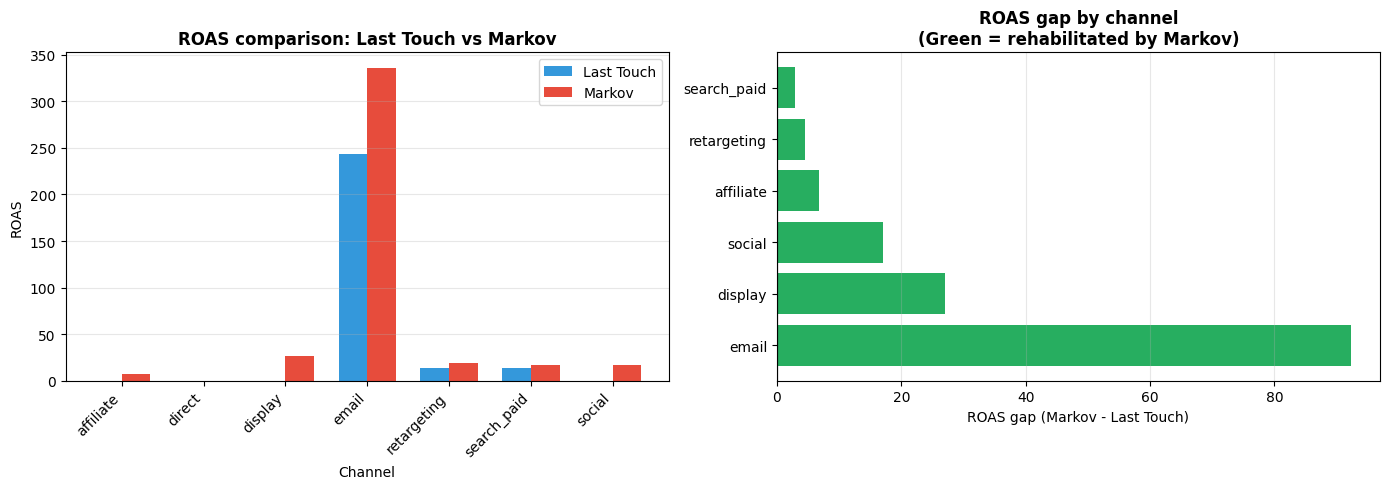


Canaux réhabilités par le modèle Markov (ROAS supérieur) :
  • email: ROAS +92.35 (Last Touch: 243.57 → Markov: 335.92)
  • display: ROAS +27.00 (Last Touch: 0.00 → Markov: 27.00)
  • social: ROAS +17.00 (Last Touch: 0.00 → Markov: 17.00)
  • affiliate: ROAS +6.82 (Last Touch: 0.00 → Markov: 6.82)
  • retargeting: ROAS +4.52 (Last Touch: 14.11 → Markov: 18.63)
  • search_paid: ROAS +2.88 (Last Touch: 14.18 → Markov: 17.06)


In [31]:
# Comparaison ROAS Last Touch vs Markov

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : ROAS par modèle
df_roas = channel_metrics[['ROAS_last_touch', 'ROAS_markov']].reset_index()
x = np.arange(len(df_roas))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, df_roas['ROAS_last_touch'], width, label='Last Touch', color='#3498db')
bars2 = ax1.bar(x + width/2, df_roas['ROAS_markov'], width, label='Markov', color='#e74c3c')

ax1.set_xlabel('Channel')
ax1.set_ylabel('ROAS')
ax1.set_title('ROAS comparison: Last Touch vs Markov', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_roas['channel'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Graphique 2 : Écart ROAS
ax2 = axes[1]
df_roas['Écart ROAS'] = df_roas['ROAS_markov'] - df_roas['ROAS_last_touch']
df_roas_sorted = df_roas.sort_values('Écart ROAS', ascending=False)
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in df_roas_sorted['Écart ROAS']]

bars = ax2.barh(df_roas_sorted['channel'], df_roas_sorted['Écart ROAS'], color=colors)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('ROAS gap (Markov - Last Touch)')
ax2.set_title('ROAS gap by channel\n(Green = rehabilitated by Markov)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse des canaux réhabilités
print("\nCanaux réhabilités par le modèle Markov (ROAS supérieur) :")
rehabilites = df_roas_sorted[df_roas_sorted['Écart ROAS'] > 0]
for _, row in rehabilites.iterrows():
    print(f"  • {row['channel']}: ROAS +{row['Écart ROAS']:.2f} (Last Touch: {row['ROAS_last_touch']:.2f} → Markov: {row['ROAS_markov']:.2f})")

In [32]:
# CPA par campagne

print("CPA (Coût par Acquisition) par campagne :")
df_campaigns_cpa = df_campaigns[['campaign_name', 'total_cost', 'n_conversions', 'cpa', 'roas']].copy()
df_campaigns_cpa.columns = ['Campagne', 'Coût Total (€)', 'Conversions', 'CPA (€)', 'ROAS']
df_campaigns_cpa

CPA (Coût par Acquisition) par campagne :


,Campagne,Coût Total (€),Conversions,CPA (€),ROAS
0,Back_to_School_2023,33567.3308,19562,1.72,69.20
1,Black_Friday_2023,33685.2149,19467,1.73,69.14
2,Spring_Launch_2024,33178.9170,19436,1.71,62.65
3,Summer_Sale_2023,33317.6850,19597,1.70,56.45
4,Valentine_2024,32863.1121,19475,1.69,23.40
5,Winter_Promo_2023,33445.5098,19596,1.71,49.10


In [33]:
# Recommandations pour le CMO

print("RECOMMANDATIONS POUR LE CMO - ATTRIBUTION MARKOV vs LAST TOUCH")

# Trouver le canal à augmenter (+20% budget)
df_roas_analysis = df_roas.copy()
df_roas_analysis['Écart ROAS'] = df_roas_analysis['ROAS_markov'] - df_roas_analysis['ROAS_last_touch']
best_channel = df_roas_analysis.loc[df_roas_analysis['Écart ROAS'].idxmax()]

# Trouver le canal à réduire
worst_channel = df_roas_analysis.loc[df_roas_analysis['Écart ROAS'].idxmin()]

print(f"\nCANAL À AUGMENTER (+20% budget) : {best_channel['channel']}")
print(f"   - Raison : ROAS Markov ({best_channel['ROAS_markov']:.2f}) supérieur au Last Touch ({best_channel['ROAS_last_touch']:.2f})")
print(f"   - Ce canal est sous-évalué par le Last Touch de {best_channel['Écart ROAS']:.2f} points")

print(f"\nCANAL À RÉDUIRE : {worst_channel['channel']}")
print(f"   - Raison : ROAS Markov ({worst_channel['ROAS_markov']:.2f}) inférieur au Last Touch ({worst_channel['ROAS_last_touch']:.2f})")
print(f"   - Ce canal est sur-évalué par le Last Touch de {abs(worst_channel['Écart ROAS']):.2f} points")

print("IMPACT SI LE CMO AVAIT BASÉ SES DÉCISIONS SUR LE LAST TOUCH :")

sous_investis = df_roas_analysis[df_roas_analysis['Écart ROAS'] > 0.5].sort_values('Écart ROAS', ascending=False)
if len(sous_investis) > 0:
    print("\nCanaux qui auraient été SOUS-INVESTIS :")
    for _, row in sous_investis.iterrows():
        ecart_pct = (row['Écart ROAS'] / row['ROAS_last_touch'] * 100) if row['ROAS_last_touch'] > 0 else 0
        print(f"   • {row['channel']}: sous-investi de {ecart_pct:.0f}% en termes de ROAS réel")

sur_investis = df_roas_analysis[df_roas_analysis['Écart ROAS'] < -0.5].sort_values('Écart ROAS')
if len(sur_investis) > 0:
    print("\nCanaux qui auraient été SUR-INVESTIS :")
    for _, row in sur_investis.iterrows():
        ecart_pct = abs(row['Écart ROAS'] / row['ROAS_last_touch'] * 100) if row['ROAS_last_touch'] > 0 else 0
        print(f"   • {row['channel']}: sur-investi de {ecart_pct:.0f}% par rapport au ROAS réel")

print("CONCLUSION :")
print("Le modèle Markov prend en compte l'ensemble du parcours client,")
print("contrairement au Last Touch qui ne crédite que le dernier point de contact.")
print("Cela permet une allocation budgétaire plus juste et efficace.")

RECOMMANDATIONS POUR LE CMO - ATTRIBUTION MARKOV vs LAST TOUCH

CANAL À AUGMENTER (+20% budget) : email
   - Raison : ROAS Markov (335.92) supérieur au Last Touch (243.57)
   - Ce canal est sous-évalué par le Last Touch de 92.35 points

CANAL À RÉDUIRE : search_paid
   - Raison : ROAS Markov (17.06) inférieur au Last Touch (14.18)
   - Ce canal est sur-évalué par le Last Touch de 2.88 points
IMPACT SI LE CMO AVAIT BASÉ SES DÉCISIONS SUR LE LAST TOUCH :

Canaux qui auraient été SOUS-INVESTIS :
   • email: sous-investi de 38% en termes de ROAS réel
   • display: sous-investi de 0% en termes de ROAS réel
   • social: sous-investi de 0% en termes de ROAS réel
   • affiliate: sous-investi de 0% en termes de ROAS réel
   • retargeting: sous-investi de 32% en termes de ROAS réel
   • search_paid: sous-investi de 20% en termes de ROAS réel
CONCLUSION :
Le modèle Markov prend en compte l'ensemble du parcours client,
contrairement au Last Touch qui ne crédite que le dernier point de contact.
Cel